<a href="https://colab.research.google.com/github/bzhuang2-create/SURF---MC-Simulation-for-Educational-Research/blob/main/MC_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title ASE and ipywidgets Install
%pip install ase
%pip install -q ipywidgets

In [ ]:
# @title Imports and Constants
%matplotlib inline

import ase
from ase import Atoms, Atom
from ase.calculators.lj import LennardJones as LJ
from ase.geometry.rdf import get_rdf
from ase.io import write
from ase.neighborlist import NeighborList

import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider
from bqplot import Figure, Lines, LinearScale
from ase.visualize.plot import plot_atoms

import numpy as np
import random
from tqdm import tqdm
import pandas as pd

from numba import njit, types
from numba.typed import Dict

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual, Layout
from ipywidgets import IntSlider, VBox
from IPython.display import clear_output

from google.colab import output
#output.enable_custom_widget_manager()

kB = 8.617e-5  # eV/K

In [40]:
# @title Lennard Jones Parameters

'''
The cantor pairing function, which maps two positive integers to a unique integer. Useful for quick data lookup for various species

Note: order matters, but subsequent definition of the property arrays give the correct properties regardless of order
a: first integer
b: second integer

returns: a unique integer
'''
@njit(fastmath=True)
def cantor_pair(a, b):
  return int(((a + b) * (a + b + 1)) // 2 + b)

'''
This is a dictionary setup using numba. Not used directly in the Monte Carlo simulation, but useful to set up the cantor pairing function array
'''

# Lennard-Jones parameter dictionary
LJ_dict = Dict.empty(key_type = types.unicode_type, value_type = types.UniTuple(types.float64, 3))

# Order: atomic number, sigma, epsilon
LJ_dict['Au'] = (79, 3.4, 0.1034)
LJ_dict['Ag'] = (47, 3.4, 0.1034)
LJ_dict['H'] = (1, 1.4, 0.1034)
LJ_dict['C'] = (6, 1.4, 0.1034)
LJ_dict['He'] = (2, 3.4, 0.1034)


'''
This is the cantor pairing function array. It stores the average LJ parameters for each pair of species as sigma ** 6 and (4)epsilon to reduce computation later.
If more species are needed, the length of the array can simply be extended
'''
LJ_avg_array = np.zeros((15000, 2), dtype=np.float64)  # (sigma^6, 4*epsilon)

for key1 in LJ_dict.keys():
  for key2 in LJ_dict.keys():
    number1, sigma1, epsilon1 = LJ_dict[key1]
    number2, sigma2, epsilon2 = LJ_dict[key2]
    LJ_avg_array[cantor_pair(number1, number2)] = (((sigma1 + sigma2) / 2) ** 6, 4 * np.sqrt(epsilon1 * epsilon2))

#https://datagrid.hu/boda/Boda-sajat/Rush/Books/Frenkel.pdf

'''
A function to calculate the Lennard-Jones interaction energy between two atoms

r2: the squared distance between the two atoms (A^2)
atom1: the atomic symbol for the first atom
atom2: the atomic symbol for the second atom
lj_avg_array: a long array of average LJ parameters. Indexed using a pairing function, which is faster than accessing a dictionary

returns: the interaction energy between the two atoms (eV)
'''
@njit(fastmath = True)
def lennard_jones(r2, atom1, atom2, lj_avg_array):

  #if(r2 == 0):
    #return 1e99
  #bootleg lmao

  sigma_6, epsilon_4 = lj_avg_array[cantor_pair(atom1, atom2)]
  #sigma ** 6 and (4)epsilon

  return epsilon_4 * (((sigma_6 ** 2) / (r2 ** 6)) - (sigma_6 / (r2 ** 3)))


In [ ]:
# @title Single and Total Energy Calculations
'''
Calculates all interaction energies for a single atom, excluding itself

atom_numbers: list of atomic numbers
atom_positions: list of atomic positions
no_atoms: total number of atoms
box_length: length of the cube (A)
selected: the index of the atom to calculate energies for
energy_fxn: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs

returns: the total interaction energies for a single atom
'''
@njit(fastmath = True)
def single_energy(atom_numbers, atom_positions, no_atoms, box_length, selected, energy_fxn, params):
  # Calculates the interaction energies for a selected atom

  energy = 0
  for i in range(no_atoms):
    if(i != selected):
      fixed_position = atom_positions[selected]
      other_position = atom_positions[i]

      dx = fixed_position[0] - other_position[0]
      dy = fixed_position[1] - other_position[1]
      dz = fixed_position[2] - other_position[2]

      # enforce periodic boundary conditions
      dx -= box_length * round(dx / box_length)
      dy -= box_length * round(dy / box_length)
      dz -= box_length * round(dz / box_length)
      r2 = (dx*dx + dy*dy + dz*dz)

      energy += energy_fxn(r2, atom_numbers[selected], atom_numbers[i], params)

  return energy

'''
Calculates the total energy of the system by finding all pairwise interaction energies and dividing by 2 to avoid double-counting

atom_numbers: list of atomic numbers
atom_positions: list of atomic positions
no_atoms: total number of atoms
box_length: length of the cube (A)
energy_fxn: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs

returns: the total interaction energies for a system
'''
@njit(fastmath = True)
def total_energy(atom_numbers, atom_positions, no_atoms, box_length, energy_fxn, params):
  energy = 0
  for i in range(no_atoms):
    energy += single_energy(atom_numbers, atom_positions, no_atoms, box_length, i, energy_fxn, params)

  return energy / 2

In [ ]:
# @title Pressure Calculations and Partial RDFs

'''
Converts a distance to a bin index for an RDF

distance: the distance to convert
R_bins: a list of distances corresponding to the RDF
'''
@njit(fastmath = True)
def distance_to_bin(distance, R_bins):
  single_radius = R_bins[1] - R_bins[0]
  # this assumes there are at least two bins, which there should be if the slider minimums are appropriate

  index = np.floor(distance / single_radius)
  return int(index)


# does direction matter?
# how many iterations should I sample for pressure?
'''
Generates a partial RDF for a specific pair of species in the system

selected_species: the atomic symbol for the first atom
target_species: the atomic symbol for the second atom
species_list: list of names of atoms (ex. ['H', 'H', 'C'])
no_atoms: total number of atoms
atom_positions: list of atomic positions, corresponding to species_list
box_length: length of the cube (A)
R_bins: a list of distances corresponding to the RDF
'''
@njit(fastmath = True)
def partial_RDF(selected_species, target_species, species_list, no_atoms, atom_positions, box_length, R_bins):
  histogram = np.zeros(len(R_bins))
  a_select_count = 0
  b_select_count = 0
  volume = box_length ** 3

  for i in range(no_atoms):
    if(species_list[i] == selected_species):
      selected_position = atom_positions[i]
      a_select_count += 1
      b_select_count = 0

      for j in range(no_atoms):
        if(species_list[j] == target_species):
          target_position = atom_positions[j]
          b_select_count += 1

          dx = selected_position[0] - target_position[0]
          dy = selected_position[1] - target_position[1]
          dz = selected_position[2] - target_position[2]

          dx -= box_length * round(dx / box_length)
          dy -= box_length * round(dy / box_length)
          dz -= box_length * round(dz / box_length)

          distance = np.sqrt(dx*dx + dy*dy + dz*dz)
          index = distance_to_bin(distance, R_bins)

          if(index < len(histogram)):
            histogram[index] += 1



  histogram = histogram / max(a_select_count * b_select_count, 1) * volume
  for i in range(len(histogram)):
    radius = R_bins[i]
    if(radius == 0):
      histogram[i] = 0
      # bootleg fix for the first zero bin
    else:
      histogram[i] = histogram[i] / (4 * np.pi * (radius ** 2) * (R_bins[1] - R_bins[0]))

  return histogram


# technically there is a tighter distance bound here (consider changing)
@njit(fastmath = True)
def bins_to_distance(box_length, no_bins):
  distances = np.zeros(no_bins)
  for i in range(no_bins):
    distances[i] = i * (box_length / 2.01) / no_bins
  return distances


'''
Calculates the various integrands of the pressure equation

atom1: atomic number of the first atom type
atom2: atomic number of the second atom type
RDF: a list corresponding to the RDF for the specific atom1/atom2 combination
R_bins: a list of distances corresponding to the RDF
energy_fxn: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs
'''
@njit(fastmath = True)
def pressure_equation(atom1, atom2, RDF, R_bins, energy_fxn, params):

  sum = 0

  for i in range(len(R_bins) - 1):
    r1 = R_bins[i]
    r2 = R_bins[i + 1]

    rp1 = r1 + 1e-3
    rn1 = r1 - 1e-3

    rp2 = r2 + 1e-3
    rn2 = r2 - 1e-3

    # avoids division by zero in LJ
    if(r1 == 0):
      rn1 = r1 + 1e-4

    dEdr2 = (energy_fxn(rp2, atom1, atom2, params) - energy_fxn(rn2, atom1, atom2, params)) / (rp2 - rn2)
    dEdr1 = (energy_fxn(rp1, atom1, atom2, params) - energy_fxn(rn1, atom1, atom2, params)) / (rp1 - rn1)

    gr2 = RDF[i + 1]
    gr1 = RDF[i]

    total2 = r2 ** 3 * gr2 * dEdr2
    total1 = r1 ** 3 * gr1 * dEdr1

    sum += (total1 + total2) * (r2 - r1) / 2


  return sum

# which mol fraction(s) do I multiply by?
'''
Given a species string and a fraction_list tuple, find the mol fraction of species

fraction_list: list of tuples of the type (Atomic Symbol, Mol Fraction)
species: string of the species to find the fraction of
'''
@njit(fastmath = True)
def find_fractions(fraction_list, species):
  for i in range(len(fraction_list)):
    if(fraction_list[i][0] == species):
      return fraction_list[i][1]

  return -1

In [43]:
# @title Simulation Helpers and Initialization
'''
Converts a given number of atoms and number density to the corresponding cube length

no_atoms: total number of atoms
rho: density (atoms per A^3)
returns: the length of the cube (A)
'''
@njit(fastmath = True)
def density_to_length(no_atoms, rho):
  # rho: atoms per A^3
  Volume = no_atoms / rho
  Length = np.cbrt(Volume)
  return Length

'''
Initializes an ASE Atoms object for the Monte Carlo Simulation

no_atoms: total number of atoms
length: length of the cube
species: list of tuples of the type (Atomic Symbol, Mol Fraction)
'''
def initialize_atoms(no_atoms, length, species):
  positions = ((np.random.rand(no_atoms, 3)) * length)

  species_string = ""
  for i in range(len(species)):
    species_string += species[i][0] * int(species[i][1] * no_atoms)

  MC = Atoms(species_string, positions, cell = [length, length, length], pbc = [True, True, True])
  return MC

def initialize_atoms_cube(no_atoms, length, species):
  dimen = int(round(no_atoms ** (1/3)))
  step = length / dimen
  positions = np.zeros((no_atoms, 3))

  species_string = ""
  for i in range(len(species)):
    species_string += species[i][0] * int(species[i][1] * no_atoms)

  for i in range(dimen):
    for j in range(dimen):
      for k in range(dimen):
        positions[i * dimen ** 2 + j * dimen + k] = [i * step, j * step, k * step]

  MC = Atoms(species_string, positions, cell = [length, length, length], pbc = [True, True, True])
  return MC

'''
Initializes the monte Carlo simulation

no_atoms: total number of atoms
density: number density of the atoms (atoms per A^3)
species: list of tuples of the type (Atomic Symbol, Mol Fraction)
cube_start: whether or not to start the atoms in a cubic lattice. NOTE: will only work if the number of atoms is a perfect cube

returns: an ASE Atoms object, with all atoms placed in random locations inside the box
'''
def MC_initial(no_atoms, density, species, cube_start):
  length = density_to_length(no_atoms, density)

  if(cube_start):
    atoms = initialize_atoms_cube(no_atoms, length, species)
  else:
    atoms = initialize_atoms(no_atoms, length, species)

  return atoms

'''
Creates a unit vector pointing in a random direction
returns: a numpy array serving as the unit vector
'''
@njit(fastmath=True)
def unit():
  vector = np.array([np.random.uniform(-1, 1), np.random.uniform(-1, 1), np.random.uniform(-1, 1)])
  return vector / np.linalg.norm(vector)


'''
Iterates the Monte Carlo simulation according to the Metropolis algorithm

no_atoms: total number of atoms
atom_numbers: list of atomic numbers
current_positions: list of atomic positions
length: length of the cube
energy_fxn: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs
step_size: the size of the step to take
n_warmup: the number of iterations to take before energy values are recorded for heat capacity
energy_array: an array to append total system energy values to
temperature: temperature (K)
i: the current iteration number
total_potential_energy: the total potential energy of the system
'''
def iterate(no_atoms, atom_numbers, current_positions, length, energy_fxn, params, step_size, n_warmup, energy_array, temperature, i, total_potential_energy):

  selected_atom = random.randrange(0, no_atoms, 1)
  current_energy = single_energy(atom_numbers, current_positions, no_atoms, length, selected_atom, energy_fxn, params)

  vector = unit() * step_size * np.random.rand()
  new_position = current_positions.copy()

  new_position[selected_atom] += vector
  new_position[selected_atom] %= length

  new_energy = single_energy(atom_numbers, new_position, no_atoms, length, selected_atom, energy_fxn, params)
  energy_difference = new_energy - current_energy

  if(energy_difference <= 0):
    current_position = new_position.copy()
    total_potential_energy += energy_difference
  else:
    probability = np.exp(-((energy_difference) / (kB * temperature)))
    if(np.random.rand() < probability):
      current_position = new_position.copy()
      total_potential_energy += energy_difference
    else:
      current_position = current_positions.copy()

  if(i > n_warmup):
    energy_array.append(total_potential_energy)

  return current_position, total_potential_energy, energy_array

In [37]:
# @title Energy-Related Helpers
'''
Finds the energy distribution of a system, accounting for all atoms

bin_size: the size of the bins to use for the histogram
no_bins: the number of bins to use for the histogram
cutoff_bins: this bin corresponds to zero energy (the bin before this index is the lowest negative energy bin, and this bin in the lowest positive energy bin)
no_atoms: total number of atoms
atom_positions: list of atom positions
atom_numbers: list of atomic numbers
box_length: length of the cube (A)
'''

@njit(fastmath = True)
def energy_to_bin(energy, bin_size, cutoff_bin):

  index_raw = int(energy / bin_size)
  index_adjust = index_raw + cutoff_bin
  return index_adjust


def find_energy_distribution(bin_size, no_bins, cutoff_bin, no_atoms, atom_positions, atom_numbers, box_length, energy_fxn, params):
  histogram = np.zeros(no_bins)

  for i in range(no_atoms):
    energy = single_energy(atom_numbers, atom_positions, no_atoms, box_length, i, energy_fxn, params)


    index = energy_to_bin(energy, bin_size, cutoff_bin)
    if(index < no_bins):
      histogram[index] += 1
    elif(index >= no_bins):
      histogram[-1] += 1
    else:
      histogram[0] += 1

  return (histogram / no_atoms, bin_size, no_bins, cutoff_bin)

In [42]:
# @title Main Function
'''
The main function which implmentes the Monte Carlo simulation according to the Metropolis algorithm
Volume, number of atoms, and temperature are fixed. Periodic boundary conditions are used.

density: number density of the atoms (atoms per A^3)
no_atoms: total number of atoms
species: list of tuples of the type (Atomic Symbol, Mol Fraction)
iterations: the mnaximum number of iterations the  simulation will complete
temperature: temperature (K)
energy: a function to calculate pairwise interaction energies. Must be of the form fxn(radius, atom#1, atom#2, params)
params: any additional parameters the user-specified energy function needs
n_warmup: after this many iterations, the simulation is assumed to be at equilibrium
'''
def MC_main(density, no_atoms, species, iterations, temperature, energy = None, params = (3.4, 0.010423, 3.4, 0.010423), n_warmup = 1000000, display_energy_profile = False, cube_start = False):
  MC = MC_initial(no_atoms, density, species, cube_start)

  energy_fxn = None
  if(energy is None):
    energy_fxn = lennard_jones
  else:
    energy_fxn = energy

  length = density_to_length(no_atoms, density)
  step_size = length / 50
  # what is a good step size?

  atom_names = MC.get_chemical_symbols()
  atom_numbers = MC.get_atomic_numbers()

  prev_energy = 1e99
  frames = []
  energy_array = []
  current_position = MC.get_positions()

  equilibrium_threshold = 1e3 # subject to change
  equilibrium_reached = False
  # right now these aren't used in any meaningful way
  # assume that the system has reached equilibrium after the specific number of iterations
  # could be a useful learning exercise for the student

  final_samples = 25 # the number of final samples to take for the RDFs
  final_sparse = 3000 # how many interations to go through between each final sample
  final_iterations = final_samples * final_sparse
  no_bins = int(12.5 * length)
  # what is a good number for these?

  total_potential_energy = total_energy(atom_numbers, current_position, no_atoms, length, energy_fxn, params)

  energy_profile_sparse = 80
  energy_profile_cutoff = 500
  # new attempt: take snapshots at fibonacci steps
  energy_profile_array = np.zeros(int(energy_profile_cutoff + (iterations - energy_profile_cutoff) / energy_profile_sparse), dtype = object)
  energy_profile_bin_size = 2e-2

  positive_bins = 5
  negative_bins = 65
  energy_profile_bin_number = positive_bins + negative_bins

  energy_profile_index = 0

  # iterates over ther user-specified number of iterations
  for i in tqdm(range(iterations), desc = "Main Iterations: "):
    current_position, total_potential_energy, energy_array = iterate(no_atoms, atom_numbers, current_position, length, energy_fxn, params, step_size, n_warmup, energy_array, temperature, i, total_potential_energy)

    # writing to OVITO - may need to change later to make it compatible with live display
    if i % 10000 == 0:
      MC.set_positions(current_position)
      frame = MC.copy()
      frame.info["step"] = i
      frame.info["temperature"] = temperature
      frames.append(frame)

    if(display_energy_profile):
      if(i < energy_profile_cutoff or i % energy_profile_sparse == 0):
        energy_profile_array[energy_profile_index] = find_energy_distribution(energy_profile_bin_size, energy_profile_bin_number, negative_bins, no_atoms, current_position, atom_numbers, length, energy_fxn, params)
        energy_profile_index += 1

  unique_species = (pd.unique(pd.Series(atom_names)))
  unique_numbers = (pd.unique(pd.Series(atom_numbers)))
  len_species = len(unique_species)

  R_bins = bins_to_distance(length, no_bins)
  raw_RDFs = np.empty((final_samples, cantor_pair(len_species, len_species)), dtype = object)

  for final in tqdm(range(final_iterations), leave = False, desc = "Finding RDFs: "):
    current_position, total_potential_energy, energy_array = iterate(no_atoms, atom_numbers, current_position, length, energy_fxn, params, step_size, n_warmup, energy_array, temperature, final, total_potential_energy)

    # only take a smple RDF every final_sparse iterations
    if(final % final_sparse == 0):
      index = final // final_sparse
      for i in range(len_species):
        for j in range(len_species):
          species1 = unique_species[i]
          species2 = unique_species[j]

          RDF = partial_RDF(species1, species2, atom_names, no_atoms, current_position, length, R_bins)
          raw_RDFs[index][cantor_pair(i, j)] = RDF

  averaged_species_RDFs = np.zeros(cantor_pair(len_species, len_species), dtype = object)

  for i in range(len_species):
    for j in range(len_species):
      sum = np.zeros(no_bins)
      for k in range(final_samples):
        sum += raw_RDFs[k][cantor_pair(i, j)]
      averaged_species_RDFs[cantor_pair(i, j)] = sum / final_samples

  manual_RDF = np.zeros(len(averaged_species_RDFs[cantor_pair(0, 0)]))
  for i in range(len_species):
    for j in range(len_species):
      fraction = find_fractions(species, unique_species[i]) * find_fractions(species, unique_species[j])
      manual_RDF += fraction * averaged_species_RDFs[cantor_pair(i, j)]
  # this is the total RDF, not the individual species RDF

  pressure_term = 0

  for i in range(len_species):
    for j in range(i, len_species):

      number1 = unique_numbers[i]
      number2 = unique_numbers[j]

      pressure_term += pressure_equation(number1, number2, averaged_species_RDFs[cantor_pair(i, j)], R_bins, energy_fxn, params)

  pressure = density * kB * temperature - pressure_term

  #ASE RDF (not species specific)
  RDF, R_bins = get_rdf(MC, length / 2.01, nbins = no_bins)

  # consider changing or removing this for updated OVITO display
  write("output.extxyz", frames)

  Cv = (np.var(energy_array)) / (no_atoms * kB * kB * temperature * temperature)
  # normalized heat capacity, 1 / atom

  if(display_energy_profile):

    return (MC, RDF, manual_RDF, averaged_species_RDFs, R_bins, no_bins, energy_profile_array, Cv, pressure)
    # energy_profile_array: histogram, bin_size, no_bins, cutoff_bin

  return (MC, RDF, manual_RDF, averaged_species_RDFs, R_bins, no_bins, Cv, pressure)


In [34]:
# @title Main Button Wrapper Function and UI

fraction_list = [('Au', 0.5), ('C', 0.5)]

'''
A wrapper function for the button. Runs the MC simulation according to what is inside of the function and loops
'''
def run_MC(null_filler = None):
  clear_output()

  Ns = np.linspace(N_slider.value[0], N_slider.value[1], atom_sweep_slider.value)
  for i in range(len(Ns)):
    Ns[i] = int(Ns[i])

  rhos = np.linspace(rho_slider.value[0], rho_slider.value[1], rho_sweep_slider.value)

  temperature = temp_slider.value

  niterations = iteration_slider.value[1]
  nwarmup = iteration_slider.value[0]

  '''
  fig1, axs1 = plt.subplots(len(rhos), len(Ns), figsize=(16, 12), sharex=True, sharey=True)
  fig1.suptitle('MC Simulation', fontsize=18)
  fig1.supxlabel('Distance (A)')
  fig1.supylabel('Radial Distribution Function')
  '''

  fig2, axs2 = plt.subplots(len(rhos), len(Ns), figsize=(16, 12), sharex=True, sharey=True)
  fig2.suptitle('Manual RDF', fontsize=18)
  fig2.supxlabel('Distance (A)')
  fig2.supylabel('Radial Distribution Function')

  fig3, axs3 = plt.subplots(len(rhos), len(Ns), figsize=(16, 12), sharex=True, sharey=True)
  fig3.suptitle('Species RDFs', fontsize=18)
  fig3.supxlabel('Distance (A)')
  fig3.supylabel('Radial Distribution Function')

  print("Running MC Simulation")

  for i in (range(len(rhos))):
    for j in range(len(Ns)):
      rho = rhos[i]
      N = int(Ns[j])

      total = N

      Result = MC_main(rho, total, fraction_list, niterations, temperature, params = LJ_avg_array, n_warmup = nwarmup)
      MC, RDF, manual_RDF, species_RDFs, R_bins, no_bins, heat_capacity, pressure = Result

      '''
      ax_c = axs1[i, j]
      ax_c.plot(R_bins, RDF, label = f"N = {N}, rho = {rho}")
      ax_c.set_title(f"N = {N}, rho = {rho}")
      ax_c.autoscale(enable = True, axis = 'both', tight = False)
      '''

      ax_m = axs2[i, j]
      ax_m.plot(R_bins, manual_RDF, label = f"N = {N}, rho = {rho}")
      ax_m.set_title(f"N = {N}, rho = {rho}")
      ax_m.autoscale(enable = True, axis = 'both', tight = False)

      ax_s = axs3[i, j]
      for a in range (len(fraction_list)):
        for b in range(a, len(fraction_list)):
          index = cantor_pair(a, b)
          ax_s.plot(R_bins, species_RDFs[index], label = f"{fraction_list[a][0]}{fraction_list[b][0]}")

      ax_s.set_title(f"N = {N}, rho = {rho}")
      ax_s.autoscale(enable = True, axis = 'both', tight = False)
      ax_s.legend()

  plt.tight_layout()
  plt.show()
  rebuild_objects()


style = {'description_width': '100px'}
width = '400px'

N_slider = widgets.IntRangeSlider(
    value = [256, 1024],        # initial range [min_selected, max_selected]
    min = 128,               # minimum possible value
    max = 2048,              # maximum possible value
    step = 32,
    description = 'Atoms:',
    style = style,
    layout = Layout(width = width)
)


rho_slider = widgets.FloatRangeSlider(
    value = [0.41, 0.82],        # initial range [min_selected, max_selected]
    min = 0.01,               # minimum possible value
    max = 1,              # maximum possible value
    step = 0.01,
    description = 'Density:',
    style = style,
    layout = Layout(width = width)
)

atom_sweep_slider = widgets.IntSlider(
    value = 2,
    min = 2,
    max = 5,
    step = 1,
    description = 'Atom Sweep:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)


rho_sweep_slider = widgets.IntSlider(
    value = 2,
    min = 2,
    max = 5,
    step = 1,
    description = 'Density Sweep:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)


temp_slider = widgets.IntSlider(
    value = 200,
    min = 0,
    max = 400,
    step = 10,
    description = 'Temperature:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)

iteration_slider = widgets.IntRangeSlider(
    value = [1e5, 2e5],        # initial range [min_selected, max_selected]
    min = 1e5,               # minimum possible value
    max = 1e7,              # maximum possible value
    step = 1e5,
    description = 'Iterations:',
    readout_format = '.1e',
    style = style,
    layout = Layout(width = width)
)

def rebuild_objects():
  display(button)
  display(N_slider)
  display(atom_sweep_slider)
  display(rho_slider)
  display(rho_sweep_slider)
  display(temp_slider)
  display(iteration_slider)

'''
Creates a button and assigns it to run the MC simulation when clicked
'''
button = widgets.Button(description = 'Run MC Simulation', disabled = False, button_style = '', tooltip = 'Run MC Simulation', icon = 'check')
button.on_click(run_MC)

rebuild_objects()

# check graphical outputs

Button(description='Run MC Simulation', icon='check', style=ButtonStyle(), tooltip='Run MC Simulation')

IntRangeSlider(value=(256, 1024), description='Atoms:', layout=Layout(width='400px'), max=2048, min=128, step=…

IntSlider(value=2, continuous_update=False, description='Atom Sweep:', layout=Layout(width='400px'), max=5, mi…

FloatRangeSlider(value=(0.41, 0.82), description='Density:', layout=Layout(width='400px'), max=1.0, min=0.01, …

IntSlider(value=2, continuous_update=False, description='Density Sweep:', layout=Layout(width='400px'), max=5,…

IntSlider(value=200, continuous_update=False, description='Temperature:', layout=Layout(width='400px'), max=40…

IntRangeSlider(value=(100000, 200000), description='Iterations:', layout=Layout(width='400px'), max=10000000, …

In [35]:
# @title Module: Energy Distribution as Simulation Progresses

energy_fraction_list = [('He', 1.0)]

x_values = []
y_values = []
energy_display = []
has_ran = False

def get_energy_profile(index):
  if(index < len(energy_display)):
    return energy_display[index][0]
  elif (index < 0):
    return energy_display[0][0]
  else:
    return energy_display[len(energy_display) - 1][0]

'''
A wrapper function for the button. Runs the MC simulation according to what is inside of the function and loops
'''
def run_MC_energy(null_filler = None):
  clear_output()

  print("Running MC Simulation - Energy Distribution Module")

  N = 343
  rho = 0.004
  # note: was 0.004 previously
  total = N

  temperature = 0.9
  niterations = energy_iteration_slider.value[1]
  nwarmup = energy_iteration_slider.value[0]

  Result = MC_main(rho, total, energy_fraction_list, niterations, temperature, params = LJ_avg_array, n_warmup = nwarmup, display_energy_profile = True, cube_start = True)
  MC, RDF, manual_RDF, species_RDFs, R_bins, no_bins, energy_profiles, heat_capacity, pressure = Result

  rebuild_energy_objects()
  global energy_display
  energy_display = energy_profiles
  # energy_profiles: list of (histogram, bin_size, no_bins, cutoff_bin)

  first_profile = energy_display[0]

  frequency_values = first_profile[0]
  bin_size = first_profile[1]
  no_bins = first_profile[2]
  cutoff_bin = first_profile[3]

  bin_values = np.zeros(int(no_bins))
  bin_values[0] = -cutoff_bin * bin_size
  for i in range(1, no_bins):
    bin_values[i] = bin_values[i - 1] + bin_size

  # updating the global variables
  global x_values
  global y_values
  global has_ran

  x_values = bin_values
  y_values = get_energy_profile(0)
  has_ran = True

style = {'description_width': '100px'}
width = '400px'

energy_temp_slider = widgets.IntSlider(
    value = 200,
    min = 0,
    max = 400,
    step = 10,
    description = 'Temperature:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)

energy_iteration_slider = widgets.IntRangeSlider(
    value = [1e5, 2e5],        # initial range [min_selected, max_selected]
    min = 1e5,               # minimum possible value
    max = 1e7,              # maximum possible value
    step = 1e5,
    description = 'Iterations:',
    readout_format = '.1e',
    style = style,
    layout = Layout(width = width)
)

def rebuild_energy_objects():
  display(energy_button)
  #display(energy_temp_slider)
  display(energy_iteration_slider)
  display(energy_interactive_plot)

'''
Creates a button and assigns it to run the MC simulation when clicked
'''
energy_button = widgets.Button(description = 'Run MC Simulation', disabled = False, button_style = '', tooltip = 'Run MC Simulation', icon = 'check')
energy_button.on_click(run_MC_energy)




def f(i = 0):
    fig, ax = plt.subplots()
    x = x_values
    if(has_ran):
      y = get_energy_profile(i)
    else:
      y = []

    plt.plot(x, y)
    plt.ylim(0, 1.0)
    #ax.xaxis.set_visible(False)
    plt.xlabel('Energy (eV)')
    plt.ylabel('Relative Frequency')
    plt.title('Energy Distribution')
    plt.show()

energy_interactive_plot = interactive(f, i = (0, 2500))
output = energy_interactive_plot.children[-1]
output.layout.height = '500px'
#display(interactive_plot)

rebuild_energy_objects()

Button(description='Run MC Simulation', icon='check', style=ButtonStyle(), tooltip='Run MC Simulation')

IntRangeSlider(value=(100000, 200000), description='Iterations:', layout=Layout(width='400px'), max=10000000, …

interactive(children=(IntSlider(value=0, description='i', max=2500), Output(layout=Layout(height='500px'))), _…

In [41]:
# @title Module: Obtaining Normalized Heat Capacity

energy_fraction_list = [('Au', 1.0)]

'''
A wrapper function for the button. Runs the MC simulation according to what is inside of the function and loops
'''
def run_MC_heat_capacity(null_filler = None):
  clear_output()

  print("Running MC Simulation - Heat Capacity Module")

  # placeholder, idk if this will be a learning module
  trials = 50
  heat_capacity_array = np.zeros(trials)

  N = 256
  rho = 0.83
  total = N

  temperature = 0.9
  niterations = energy_iteration_slider.value[1]
  nwarmup = energy_iteration_slider.value[0]

  for i in range(trials):
    Result = MC_main(rho, total, energy_fraction_list, niterations, temperature, params = LJ_avg_array, n_warmup = nwarmup)
    MC, RDF, manual_RDF, species_RDFs, R_bins, no_bins, heat_capacity, pressure = Result
    heat_capacity_array[i] = heat_capacity
    #print(heat_capacity)

  heat_capacity_average = np.average(heat_capacity_array)
  heat_capacity_error = np.std(heat_capacity_array)

  print(f"The average normalized heat capacity is {heat_capacity_average} +/- {heat_capacity_error} 1 / atom")
  plt.hist(heat_capacity_array)
  plt.xlabel('Heat Capacity (1 / atom)')
  plt.ylabel('Frequency')
  plt.title('Heat Capacity Distribution')

  rebuild_energy_objects()


style = {'description_width': '100px'}
width = '400px'

heat_capacity_temp_slider = widgets.IntSlider(
    value = 200,
    min = 0,
    max = 400,
    step = 10,
    description = 'Temperature:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)

heat_capacity_iteration_slider = widgets.IntRangeSlider(
    value = [1.5e5, 2e5],        # initial range [min_selected, max_selected]
    min = 1e5,               # minimum possible value
    max = 1e7,              # maximum possible value
    step = 1e5,
    description = 'Iterations:',
    readout_format = '.1e',
    style = style,
    layout = Layout(width = width)
)

def rebuild_energy_objects():
  display(heat_capacity_button)
  #display(heat_capacity_temp_slider)
  display(heat_capacity_iteration_slider)

'''
Creates a button and assigns it to run the MC simulation when clicked
'''
heat_capacity_button = widgets.Button(description = 'Run MC Simulation', disabled = False, button_style = '', tooltip = 'Run MC Simulation', icon = 'check')
heat_capacity_button.on_click(run_MC_heat_capacity)

rebuild_energy_objects()

Running MC Simulation - Heat Capacity Module


Main Iterations:   0%|          | 2/200000 [00:00<5:18:39, 10.46it/s] 


UnboundLocalError: cannot access local variable 'total_potantial_energy' where it is not associated with a value

Running MC Simulation - Pressure Module


Main Iterations: 100%|██████████| 2000000/2000000 [02:17<00:00, 14522.87it/s]


Button(description='Run MC Simulation', icon='check', style=ButtonStyle(), tooltip='Run MC Simulation')

IntRangeSlider(value=(1500000, 2000000), description='Iterations:', layout=Layout(width='400px'), max=10000000…

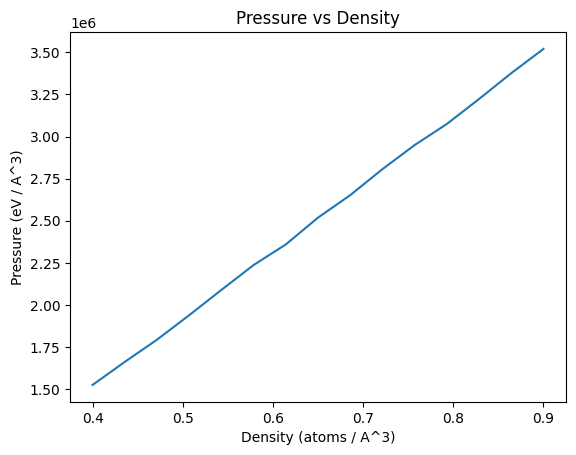

In [39]:
# @title Module: Obtaining Pressure and Virial Coefficients

pressure_fraction_list = [('Au', 1.0)]

'''
A wrapper function for the button. Runs the MC simulation according to what is inside of the function and loops
'''
def run_MC_pressure(null_filler = None):
  clear_output()

  print("Running MC Simulation - Pressure Module")

  iterations = 15
  pressure_array = np.zeros(iterations)

  no_atoms = 256
  rhos = np.linspace(0.4, 0.9, iterations)
  # consider making this a slider


  temperature = 0.9
  niterations = pressure_iteration_slider.value[1]
  nwarmup = pressure_iteration_slider.value[0]

  for i in range(len(rhos)):
    rho = rhos[i]
    Result = MC_main(rho, no_atoms, pressure_fraction_list, niterations, temperature, params = LJ_avg_array, n_warmup = nwarmup)
    MC, RDF, manual_RDF, species_RDFs, R_bins, no_bins, heat_capacity, pressure = Result
    pressure_array[i] = pressure
    #print(pressure)

  plt.plot(rhos, pressure_array)
  plt.xlabel('Density (atoms / A^3)')
  plt.ylabel('Pressure (eV / A^3)')
  plt.title('Pressure vs Density')

  rebuild_pressure_objects()


style = {'description_width': '100px'}
width = '400px'

pressure_temp_slider = widgets.IntSlider(
    value = 200,
    min = 0,
    max = 400,
    step = 10,
    description = 'Temperature:',
    disabled = False,
    continuous_update = False,
    orientation = 'horizontal',
    readout = True,
    readout_format = 'd',
    style = style,
    layout = Layout(width = width)
)

pressure_iteration_slider = widgets.IntRangeSlider(
    value = [3e5, 4e5],        # initial range [min_selected, max_selected]
    min = 1e5,               # minimum possible value
    max = 1e7,              # maximum possible value
    step = 1e5,
    description = 'Iterations:',
    readout_format = '.1e',
    style = style,
    layout = Layout(width = width)
)

def rebuild_pressure_objects():
  display(pressure_button)
  #display(pressure_temp_slider)
  display(pressure_iteration_slider)

'''
Creates a button and assigns it to run the MC simulation when clicked
'''
pressure_button = widgets.Button(description = 'Run MC Simulation', disabled = False, button_style = '', tooltip = 'Run MC Simulation', icon = 'check')
pressure_button.on_click(run_MC_pressure)

rebuild_pressure_objects()

In [ ]:
# @title
# spare code, in case implmentation requires it again

'''
# separate dictionary for average LJ values
LJ_avg_dict = Dict.empty(key_type = types.unicode_type, value_type = types.UniTuple(types.float64, 2))

for key1 in LJ_dict.keys():
  for key2 in LJ_dict.keys():
    sigma1, epsilon1 = LJ_dict[key1]
    sigma2, epsilon2 = LJ_dict[key2]

    LJ_avg_dict[key1 + key2] = (((sigma1 + sigma2) / 2) ** 6, 4 * np.sqrt(epsilon1 * epsilon2))
'''

In [ ]:
# @title
#testing cell
'''
import ase
from ase import Atoms, Atom
from ase.calculators.lj import LennardJones as LJ
from ase.geometry.rdf import get_rdf
from ase.build import molecule

import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

import numpy as np
import random

test1 = Atoms("H2", [[0, 0, 0], [1.0, 0, 0]])
test2 = Atoms("C", [[0, 1.5, 0]])
test3 = Atoms("B2", [[0, 1.5, 0], [9, 9, 9]])
test4 = Atoms([Atom('C', [0., 2., 0.]),
               Atom('O', [1.1, 0., 3.])],
              cell=(10, 10, 10))
test5 = molecule("SiH4")
test6 = molecule("H2O2")
test7 = molecule("H2O")

test = test1 + test2 + test3 + test4 + test5 + test6 + test7
print(test)
print(test.get_positions())
print(test.get_atomic_numbers())

fig, ax = plt.subplots()
plot_atoms(test, ax, rotation='45x,45y,45z')
plt.show()
'''